In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve,
    f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [8]:
# Load data
import os
import shutil
import subprocess

DATA_PATH = 'creditcard.csv'

# The dataset is intentionally excluded from Git tracking (too large for GitHub).
# Place it in this folder (or update DATA_PATH) to run the notebook.

def _download_from_kaggle():
    kaggle_cmd = shutil.which('kaggle')
    if not kaggle_cmd:
        return False, 'kaggle CLI not found'

    print('Dataset not found. Attempting to download via Kaggle CLI...')
    proc = subprocess.run(
        [kaggle_cmd, 'datasets', 'download', '-d', 'mlg-ulb/creditcardfraud', '-f', 'creditcard.csv', '-p', '.', '--unzip'],
        capture_output=True,
        text=True,
    )

    if proc.returncode != 0:
        return False, proc.stderr.strip() or proc.stdout.strip()

    return os.path.exists(DATA_PATH), ''

if not os.path.exists(DATA_PATH):
    ok, reason = _download_from_kaggle()
    if not ok:
        raise FileNotFoundError(
            f"{DATA_PATH} not found.\n"
            "Download it from Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) "
            "and place it in this folder, or update DATA_PATH to point to your local copy.\n"
            "If you prefer keeping the file out of git, add it to .gitignore (already set up in this repo).\n"
            + (f"\nKaggle download attempt failed: {reason}" if reason else "")
        )

# NOTE: This file is large (~145MB) and is intentionally excluded from the repository to keep the repo pushable to GitHub.
# You can download it locally and rerun this cell.

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
df.head()

Dataset shape: (284807, 31)
Memory usage: 67.4 MB

Missing values: 0
Duplicate rows: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
# Class distribution — the core challenge
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print('='*50)
print('CLASS DISTRIBUTION')
print('='*50)
print(f'Legitimate (0): {fraud_counts[0]:>10,} ({fraud_pct[0]:.3f}%)')
print(f'Fraudulent (1): {fraud_counts[1]:>10,} ({fraud_pct[1]:.3f}%)')
print(f'Imbalance ratio: 1:{fraud_counts[0]//fraud_counts[1]}')
print('='*50)

CLASS DISTRIBUTION
Legitimate (0):    284,315 (99.827%)
Fraudulent (1):        492 (0.173%)
Imbalance ratio: 1:577


In [10]:
print('\n⚠️  This extreme imbalance (1:578) means accuracy is meaningless.')
print('   A naive classifier predicting all "legitimate" gets 99.83% accuracy.')
print('   We need precision-recall focused evaluation.')


⚠️  This extreme imbalance (1:578) means accuracy is meaningless.
   A naive classifier predicting all "legitimate" gets 99.83% accuracy.
   We need precision-recall focused evaluation.


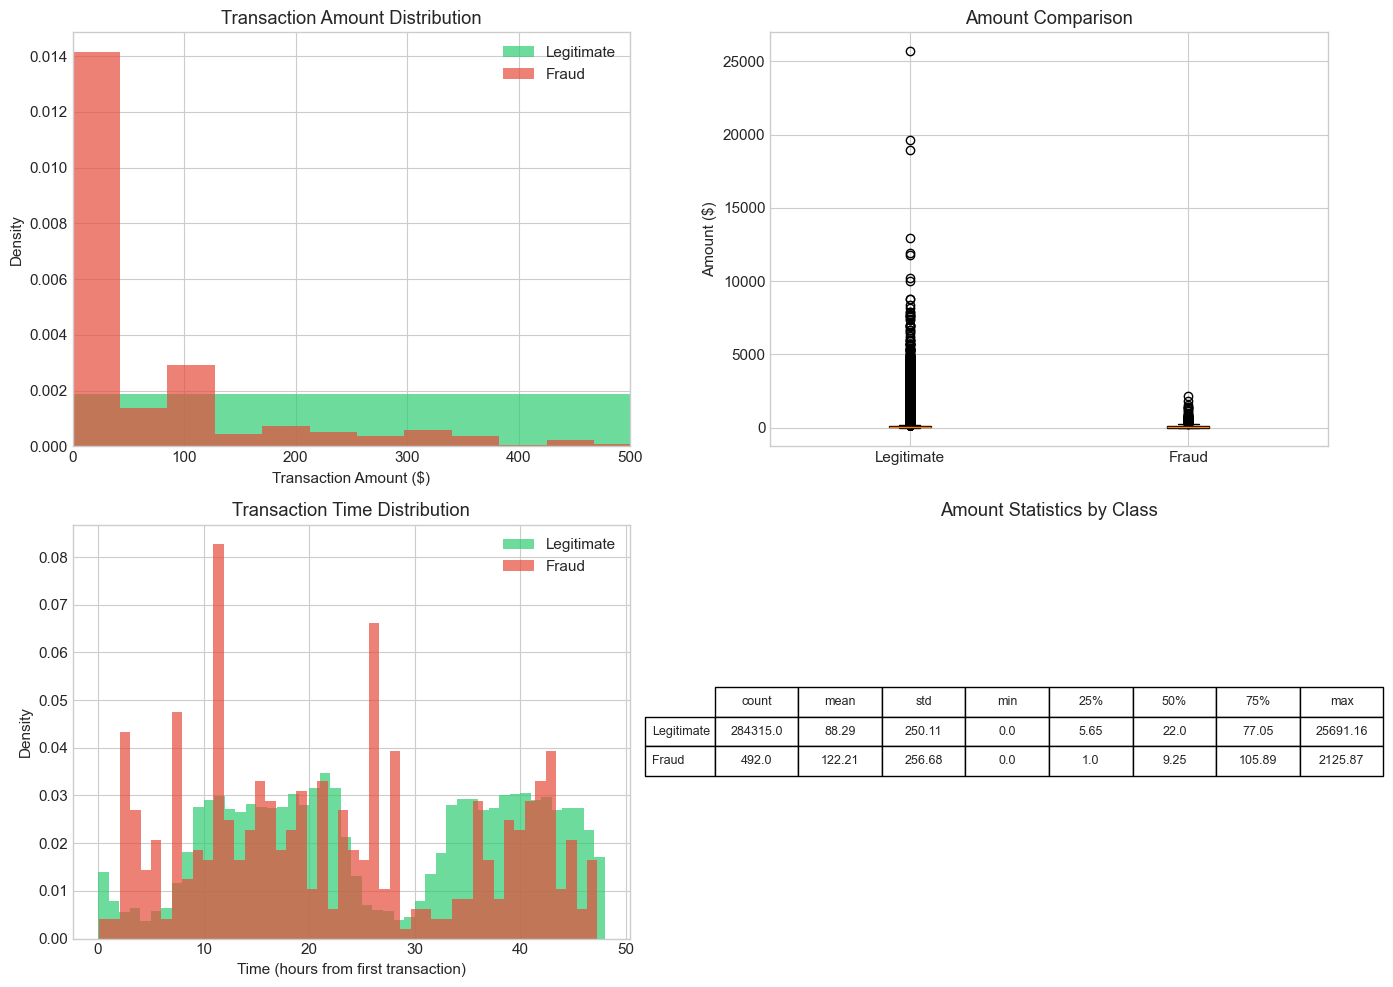

In [11]:
# Transaction amount and time analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution by class
axes[0, 0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, 
                label='Legitimate', color='#2ecc71', density=True)
axes[0, 0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, 
                label='Fraud', color='#e74c3c', density=True)
axes[0, 0].set_xlabel('Transaction Amount ($)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Transaction Amount Distribution')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 500)

# Amount boxplot
fraud_data = [df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']]
# Matplotlib 3.9 renamed `labels` to `tick_labels`; this avoids a deprecation warning.
bp = axes[0, 1].boxplot(fraud_data, tick_labels=['Legitimate', 'Fraud'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0, 1].set_ylabel('Amount ($)')
axes[0, 1].set_title('Amount Comparison')

# Time distribution
axes[1, 0].hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.7, 
                label='Legitimate', color='#2ecc71', density=True)
axes[1, 0].hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.7, 
                label='Fraud', color='#e74c3c', density=True)
axes[1, 0].set_xlabel('Time (hours from first transaction)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Transaction Time Distribution')
axes[1, 0].legend()

# Fraud amount summary stats
stats_data = df.groupby('Class')['Amount'].describe().round(2)
axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=stats_data.values,
    rowLabels=['Legitimate', 'Fraud'],
    colLabels=stats_data.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Amount Statistics by Class')

plt.tight_layout()
plt.show()

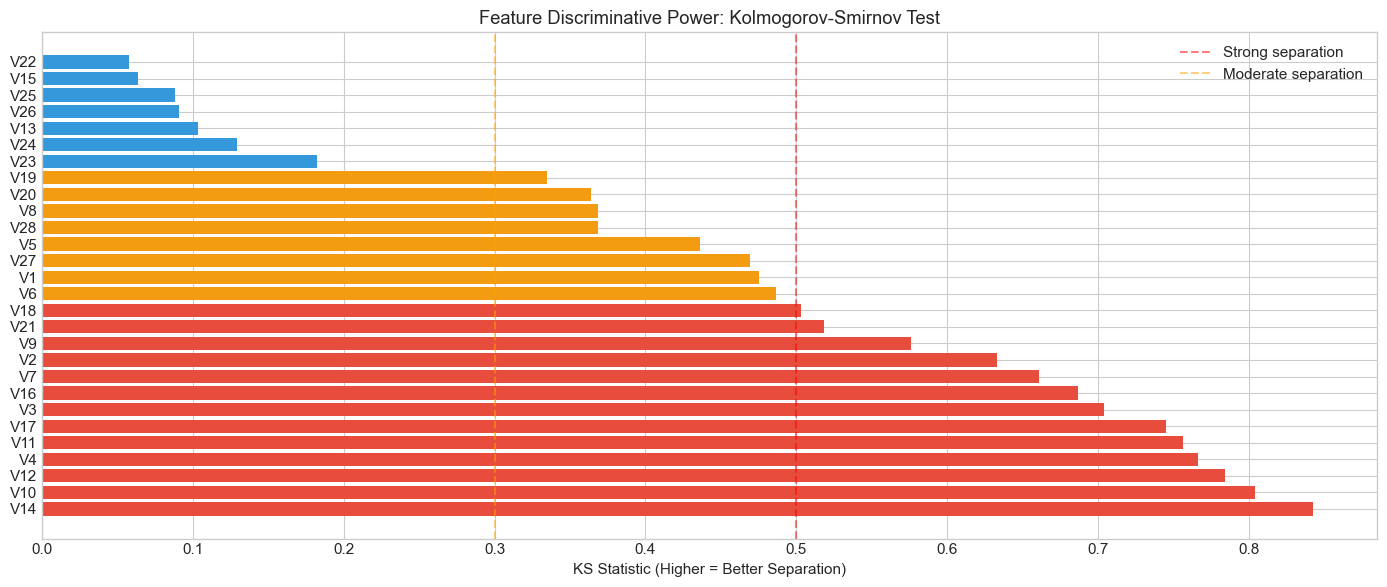


🔑 Top discriminative features: V14, V10, V12, V4, V11, V17, V3, V16


In [12]:
# Feature separation analysis — which PCA features best distinguish fraud?
# Using Kolmogorov-Smirnov test to quantify distribution differences

v_features = [f'V{i}' for i in range(1, 29)]
ks_results = []

for feat in v_features:
    legit = df[df['Class']==0][feat]
    fraud = df[df['Class']==1][feat]
    ks_stat, p_val = stats.ks_2samp(legit, fraud)
    mean_diff = abs(fraud.mean() - legit.mean())
    ks_results.append({
        'Feature': feat,
        'KS_Statistic': ks_stat,
        'Mean_Difference': mean_diff,
        'Fraud_Mean': fraud.mean(),
        'Legit_Mean': legit.mean()
    })

ks_df = pd.DataFrame(ks_results).sort_values('KS_Statistic', ascending=False)

# Plot top discriminative features
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if x > 0.5 else '#f39c12' if x > 0.3 else '#3498db' 
          for x in ks_df['KS_Statistic']]
bars = ax.barh(ks_df['Feature'], ks_df['KS_Statistic'], color=colors)
ax.set_xlabel('KS Statistic (Higher = Better Separation)')
ax.set_title('Feature Discriminative Power: Kolmogorov-Smirnov Test')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Strong separation')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Moderate separation')
ax.legend()
plt.tight_layout()
plt.show()

top_features = ks_df.head(8)['Feature'].tolist()
print(f'\n🔑 Top discriminative features: {", ".join(top_features)}')

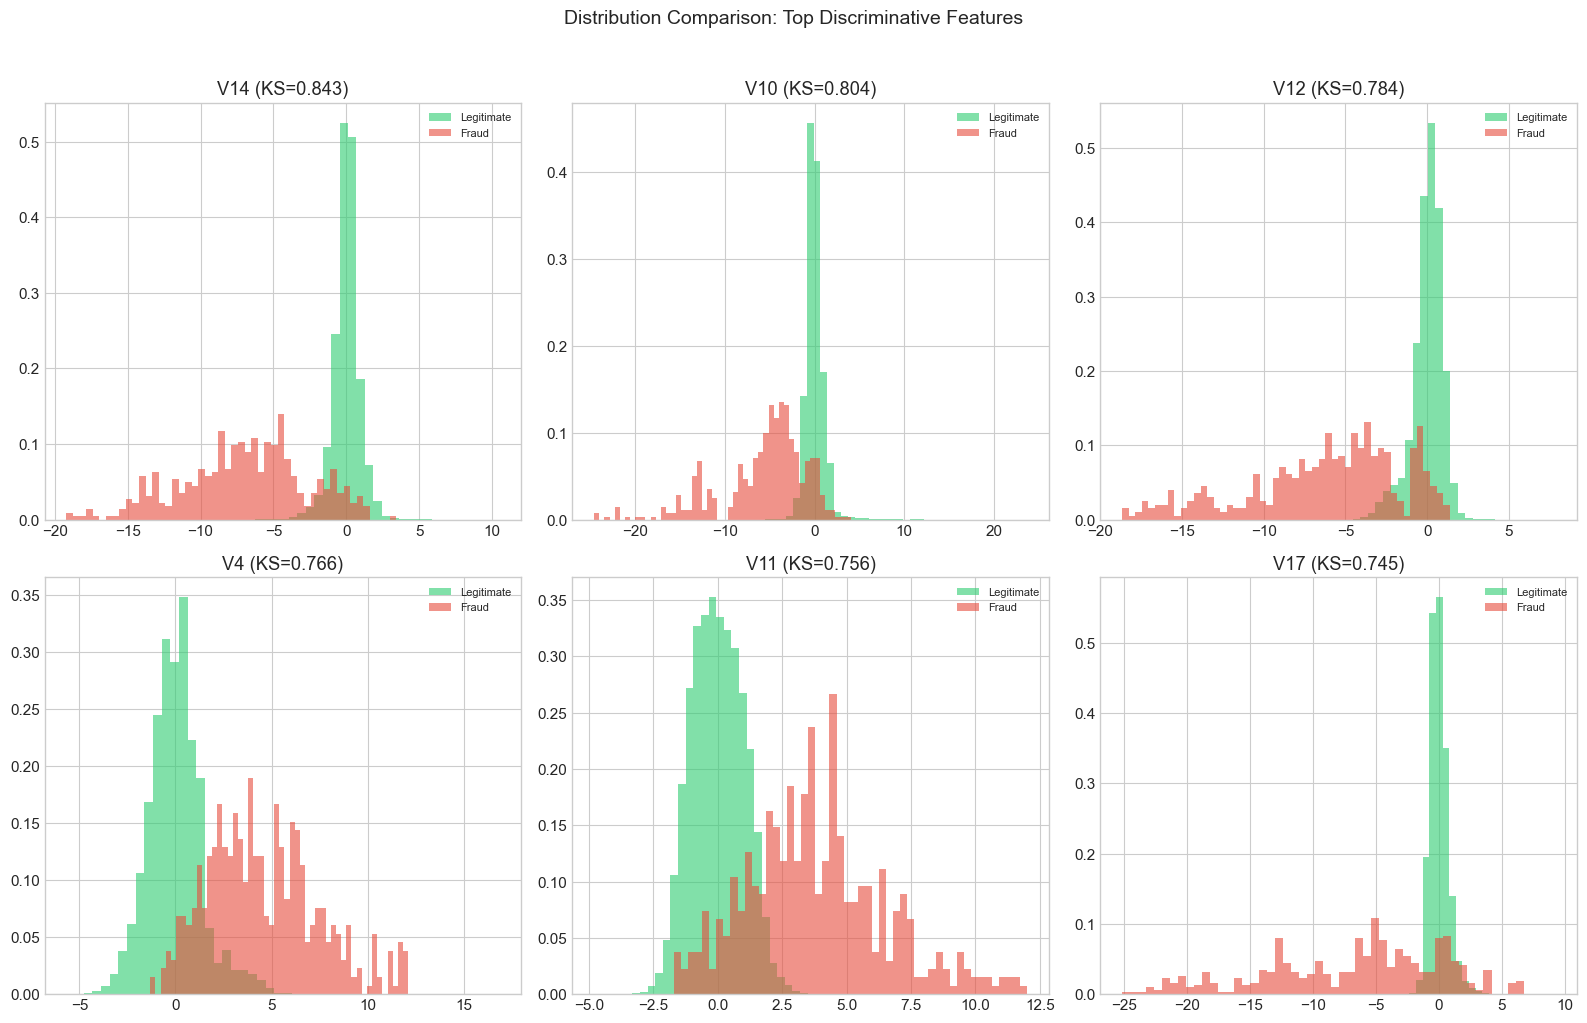

In [13]:
# Distribution comparison for top 6 most discriminative features
top_6 = ks_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_6):
    ax = axes[i]
    legit_vals = df[df['Class']==0][feat]
    fraud_vals = df[df['Class']==1][feat]
    
    ax.hist(legit_vals, bins=50, alpha=0.6, label='Legitimate', 
            color='#2ecc71', density=True)
    ax.hist(fraud_vals, bins=50, alpha=0.6, label='Fraud', 
            color='#e74c3c', density=True)
    ax.set_title(f'{feat} (KS={ks_df[ks_df["Feature"]==feat]["KS_Statistic"].values[0]:.3f})')
    ax.legend(fontsize=8)

plt.suptitle('Distribution Comparison: Top Discriminative Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 📊 EDA Insights

**Key findings:**
- Extreme class imbalance (0.17% fraud) — evaluation must focus on precision-recall, not accuracy
- Fraud transactions tend to have lower amounts on average (counter-intuitive but common — fraudsters test with small amounts)
- Several PCA features show strong separation (V14, V12, V10, V17) — these will be important for model interpretability
- Fraud shows different temporal patterns — certain time windows have higher fraud density

<a id='3'></a>
## 3. Feature Engineering & Preprocessing

Since most features are PCA-transformed, our engineering focuses on:
- Scaling `Amount` and `Time` to match PCA features
- Creating interaction features from top discriminative features
- Time-based features

In [14]:
# Feature Engineering
df_eng = df.copy()

# Scale Amount and Time using RobustScaler (resistant to outliers)
rob_scaler = RobustScaler()
df_eng['Amount_scaled'] = rob_scaler.fit_transform(df_eng['Amount'].values.reshape(-1, 1))
df_eng['Time_scaled'] = rob_scaler.fit_transform(df_eng['Time'].values.reshape(-1, 1))

# Time-based features
df_eng['Hour'] = (df_eng['Time'] % (24 * 3600)) / 3600  # Hour of day (cyclic)
df_eng['Is_Night'] = ((df_eng['Hour'] >= 22) | (df_eng['Hour'] <= 6)).astype(int)

# Interaction features from top discriminative pairs
df_eng['V14_V12'] = df_eng['V14'] * df_eng['V12']
df_eng['V14_V10'] = df_eng['V14'] * df_eng['V10']
df_eng['V17_V14'] = df_eng['V17'] * df_eng['V14']

# Amount-based features
df_eng['Log_Amount'] = np.log1p(df_eng['Amount'])
df_eng['Amount_V14'] = df_eng['Amount_scaled'] * df_eng['V14']  # Amount × top fraud indicator

# Drop original Time and Amount
df_eng.drop(['Time', 'Amount'], axis=1, inplace=True)

print(f'Engineered dataset shape: {df_eng.shape}')
print(f'New features added: {df_eng.shape[1] - df.shape[1] + 2}')
print(f'\nNew features: Amount_scaled, Time_scaled, Hour, Is_Night, V14_V12, V14_V10, V17_V14, Log_Amount, Amount_V14')

Engineered dataset shape: (284807, 38)
New features added: 9

New features: Amount_scaled, Time_scaled, Hour, Is_Night, V14_V12, V14_V10, V17_V14, Log_Amount, Amount_V14


In [15]:
# Train-test split with stratification
X = df_eng.drop('Class', axis=1)
y = df_eng['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples ({y_train.sum():,} fraud)')
print(f'Test set:     {X_test.shape[0]:,} samples ({y_test.sum():,} fraud)')
print(f'\nFraud ratio preserved: Train={y_train.mean():.4f}, Test={y_test.mean():.4f}')

Training set: 227,845 samples (394 fraud)
Test set:     56,962 samples (98 fraud)

Fraud ratio preserved: Train=0.0017, Test=0.0017


<a id='4'></a>
## 4. Handling Class Imbalance — Strategy Comparison

This is where most notebooks fall short. Instead of blindly applying SMOTE, let's **systematically compare** resampling strategies:

| Strategy | Approach | Pros | Cons |
|----------|----------|------|------|
| **No resampling** | Baseline | No information loss | Biased toward majority |
| **SMOTE** | Synthetic oversampling | Preserves all real data | Can create noisy samples |
| **Random Undersampling** | Remove majority samples | Balanced quickly | Loses information |

In [16]:
# Compare resampling strategies using cross-validation
resampling_strategies = {
    'No Resampling': None,
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'Random Undersampling': RandomUnderSampler(random_state=RANDOM_STATE),
}

# Use LightGBM as base model for speed
base_model = LGBMClassifier(
    n_estimators=100, random_state=RANDOM_STATE, verbose=-1,
    is_unbalance=True
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
resampling_results = {}

print('Evaluating resampling strategies (3-fold CV)...')
print('-' * 60)

for name, sampler in resampling_strategies.items():
    if sampler is None:
        model = base_model
    else:
        model = ImbPipeline([
            ('sampler', sampler),
            ('model', LGBMClassifier(
                n_estimators=100, random_state=RANDOM_STATE, verbose=-1
            ))
        ])
    
    scores = cross_val_score(model, X_train, y_train, cv=cv, 
                            scoring='average_precision', n_jobs=-1)
    resampling_results[name] = scores
    print(f'{name:25s} | AP: {scores.mean():.4f} ± {scores.std():.4f}')

print('-' * 60)
print('\n✅ AP = Average Precision (area under precision-recall curve)')
print('   This is the gold standard metric for imbalanced classification.')

Evaluating resampling strategies (3-fold CV)...
------------------------------------------------------------
No Resampling             | AP: 0.0492 ± 0.0236
SMOTE                     | AP: 0.8096 ± 0.0178
Random Undersampling      | AP: 0.6940 ± 0.0293
------------------------------------------------------------

✅ AP = Average Precision (area under precision-recall curve)
   This is the gold standard metric for imbalanced classification.


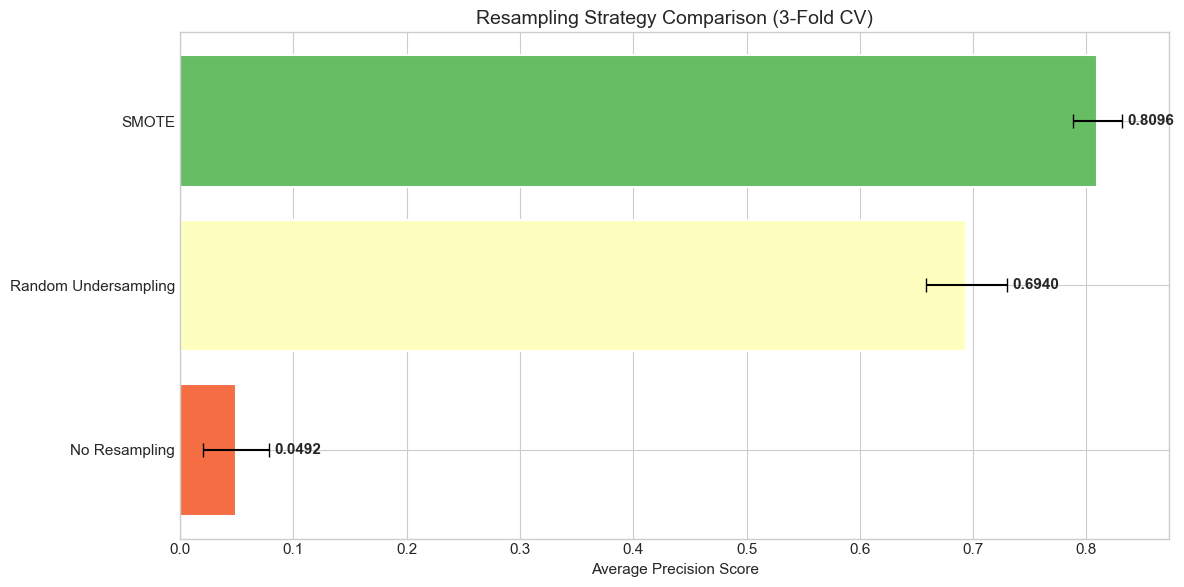

In [17]:
# Visualize resampling comparison
fig, ax = plt.subplots(figsize=(12, 6))

results_df = pd.DataFrame(resampling_results)
means = results_df.mean().sort_values(ascending=True)
stds = results_df.std()[means.index]

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(means)))
bars = ax.barh(means.index, means.values, xerr=stds.values, 
               color=colors, capsize=5, edgecolor='white', linewidth=1.5)

for bar, mean, std in zip(bars, means.values, stds.values):
    ax.text(mean + std + 0.005, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')

ax.set_xlabel('Average Precision Score')
ax.set_title('Resampling Strategy Comparison (3-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()